# Confronto tra Insertion Sort e Bubble Sort

> Lorenzo Malavolti (Matricola 7048432)
>
> Università degli studi di Firenze
>
> Laboratorio di Algoritmi, Esercizio B

## Introduzione
Lo scopo di questo notebook è confrontare le prestazioni di due algoritmi di ordinamento: Insertion Sort e Bubble Sort.
>
Per semplicità, si suppone che le liste da ordinare contengano solo numeri interi anche se gli algoritmi funzionano con qualsiasi tipo di dato ordinabile (ad esempio stringhe o date).


## Cenni Teorici
### Problema dell'ordinamento
Data una sequenza di n elementi, l'obiettivo è riordinarli in modo crescente (o decrescente) secondo un criterio di ordinamento definito.

### Insertion Sort
L'Insertion Sort è un algoritmo di ordinamento che costruisce l'ordinamento finale un elemento alla volta. Per ogni elemento, lo confronta con quelli già ordinati e lo inserisce nella posizione corretta. In particolare, sposta gli elementi più grandi di una posizione a destra per fare spazio al nuovo elemento.

<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/3/32/Insertionsort-before.png"
         alt="Schema Insertion Sort prima dell'iterazione">
         <br>
    <small><i>(Fig. 1): Stato dell'array prima di un'iterazione dell'Insertion Sort.</i></small>
</div>

<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/d/d9/Insertionsort-after.png"
         alt="Schema Insertion Sort dopo iterazione">
         <br>
    <small><i>(Fig. 1): Stato dell'array prima di un'iterazione dell'Insertion Sort.</i></small>
</div>

### Complessità
Questo algoritmo ha una complessità temporale di $O(n^2)$ nel caso peggiore (quando la lista è ordinata in modo decrescente) e $\Omega(n)$ nel caso migliore (quando la lista è già ordinata). Nel caso medio, la complessità è $O(n^2)$.

<div align="center">

| Caso Migliore | Caso Medio | Caso Peggiore |
|:-------------:|:----------:|:-------------:|
|  $\Omega(n)$  |  $O(n^2)$  |   $O(n^2)$    |
</div>

Dalle complessità sopra riportate, vediamo che questo algoritmo è particolarmente efficiente per liste già ordinate o quasi ordinate, ma diventa inefficiente per liste di grandi dimensioni che sono in ordine inverso.

### Esempi
<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/0/0f/Insertion-sort-example-300px.gif"
         height="150px"
         alt="Schema Insertion Sort dopo iterazione">
         <br>
</div>

In [3]:
#Insertion Sort
def insertion_sort(A: list):
    for i in range(1, len(A)):
        key = A[i]
        j = i - 1
        while j >= 0 and key < A[j]:
            A[j + 1] = A[j]
            j -= 1
        A[j + 1] = key

### Bubble Sort
Il Bubble Sort è un algoritmo di ordinamento semplice che ripetutamente scorre la lista, confronta elementi adiacenti e li scambia se sono nell'ordine sbagliato. Il processo viene ripetuto fino a quando la lista è ordinata.

### Complessità
Il Bubble Sort ha una complessità temporale di $O(n^2)$ sia nel caso peggiore che nel caso medio, e $O(n)$ nel caso migliore (quando la lista è già ordinata). Tuttavia, senza l'ottimizzazione con un flag, il Bubble Sort rimane $O(n^2)$ anche nel caso migliore.

<div align="center">

| Caso Migliore | Caso Medio | Caso Peggiore |
|:-------------:|:----------:|:-------------:|
|   $O(n^2)$    |  $O(n^2)$  |   $O(n^2)$    |
</div>

Dalla tabella sopra, vediamo che il Bubble Sort è inefficiente per liste di grandi dimensioni, indipendentemente dall'ordinamento iniziale.

### Esempi
<div align="center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/c/c8/Bubble-sort-example-300px.gif"
         height="150px"
         alt="Schema Bubble Sort dopo iterazione">
         <br>
</div>

In [4]:
#Bubble Sort
def bubble_sort(A):
    n = len(A)
    for i in range(n):
        # Il ciclo interno fa risalire l'elemento più piccolo
        for j in range(n - 1, i, -1):
            if A[j] < A[j - 1]:
                A[j], A[j - 1] = A[j - 1], A[j]

## Ambiente di esecuzione
Per eseguire i test, utilizzeremo un ambiente Python con le seguenti librerie:
- `time`: per misurare il tempo di esecuzione degli algoritmi.
- `random`: per generare array di numeri interi casuali.
- `matplotlib`: per visualizzare i risultati dei test tramite grafici.

Di seguito, verranno eseguiti i test e visualizzati i risultati in modo chiaro e comprensibile, permettendo un confronto diretto tra i due algoritmi nei diversi scenari di ordinamento.

## Descrizione dei test
Per confrontare le prestazioni dei due algoritmi, eseguiremo una serie di test su array di dimensioni crescenti (100, 250, 500, 750, 1000, 1250). Per ogni dimensione, testeremo tre casi distinti:
1. **Caso Medio (Random)**: Un array di numeri interi generati casualmente.
2. **Caso Migliore (Già Ordinato)**: Un array già ordinato in modo crescente.
3. **Caso Peggiore (Decrescente)**: Un array ordinato in modo decrescente.

Nota: Per garantire la riproducibilità dei test, utilizzeremo un seed fisso per la generazione dei numeri casuali. Inoltre, misureremo il tempo di esecuzione di ciascun algoritmo utilizzando `time.perf_counter()`, che offre una maggiore precisione rispetto a `time.time()`. Infine, visualizzeremo i risultati tramite grafici per facilitare il confronto tra i due algoritmi nei diversi scenari.

## Generazione dei dati di test
Le seguenti funzioni generano un array con $n$ valori, con $n$ che va da 1 a 1250. I valori sono compresi tra 0 e 10000. Per garantire la riproducibilità dei test, utilizziamo un generatore di numeri casuali con un seed fisso.
>
La prima funzione `random_array(n)` genera un array di $n$ numeri interi casuali. La seconda funzione `sorted_array(n)` genera un array ordinato in modo crescente, mentre la terza funzione `reverse_array(n)` genera un array ordinato in modo decrescente.

In [7]:
import numpy as np

max_value = 10000
# Il seme 42 garantisce che random_array generi sempre la stessa sequenza
rng = np.random.default_rng(seed=42)

def random_array(n):
    return rng.integers(0, max_value + 1, size=n).tolist()

def sorted_array(n):
    return np.arange(n).tolist()

def reverse_array(n):
    # Genera numeri da n-1 a 0
    return np.arange(n - 1, -1, -1).tolist()

## Esecuzione dei test
Gli algoritmi vengono testati su dimensioni crescenti (100, 250, 500, 750, 1000, 1250) per i tre casi distinti: random, ordinato e decrescente per osservare come il tempo di esecuzione varia in base alla dimensione dell'array e al tipo di ordinamento iniziale.
>
Viene utilizzata una funzione `run_benchmark` che prende in input l'algoritmo da testare e i dati su cui eseguirlo. Questa funzione inoltre effettua una copia dei dati per evitare che l'ordinamento di un algoritmo influenzi i test successivi.
>
Il tempo di esecuzione viene misurato utilizzando `time.perf_counter()`. I risultati vengono raccolti in un dizionario per facilitare la visualizzazione successiva.


In [9]:
import time

def run_benchmark(algorithm, data):
    # Usiamo una copia per non sporcare i dati per l'algoritmo successivo
    arr_copy = data.copy()
    start_time = time.perf_counter() # Più preciso di time.time()
    algorithm(arr_copy)
    return time.perf_counter() - start_time

# Configurazioni del test
sizes = [100, 250, 500, 750, 1000, 1250]
results = {
    "bubble_random": [], "insertion_random": [],
    "bubble_sorted": [], "insertion_sorted": [],
    "bubble_reverse": [], "insertion_reverse": []
}

for n in sizes:
    # Generazione dei casi
    random_case = random_array(n)
    sorted_case = sorted_array(n)
    reverse_case = reverse_array(n)

    # Esecuzione test
    results["bubble_random"].append(run_benchmark(bubble_sort, random_case))
    results["insertion_random"].append(run_benchmark(insertion_sort, random_case))

    results["bubble_sorted"].append(run_benchmark(bubble_sort, sorted_case))
    results["insertion_sorted"].append(run_benchmark(insertion_sort, sorted_case))

    results["bubble_reverse"].append(run_benchmark(bubble_sort, reverse_case))
    results["insertion_reverse"].append(run_benchmark(insertion_sort, reverse_case))

print("Benchmark completato!")

Benchmark completato!


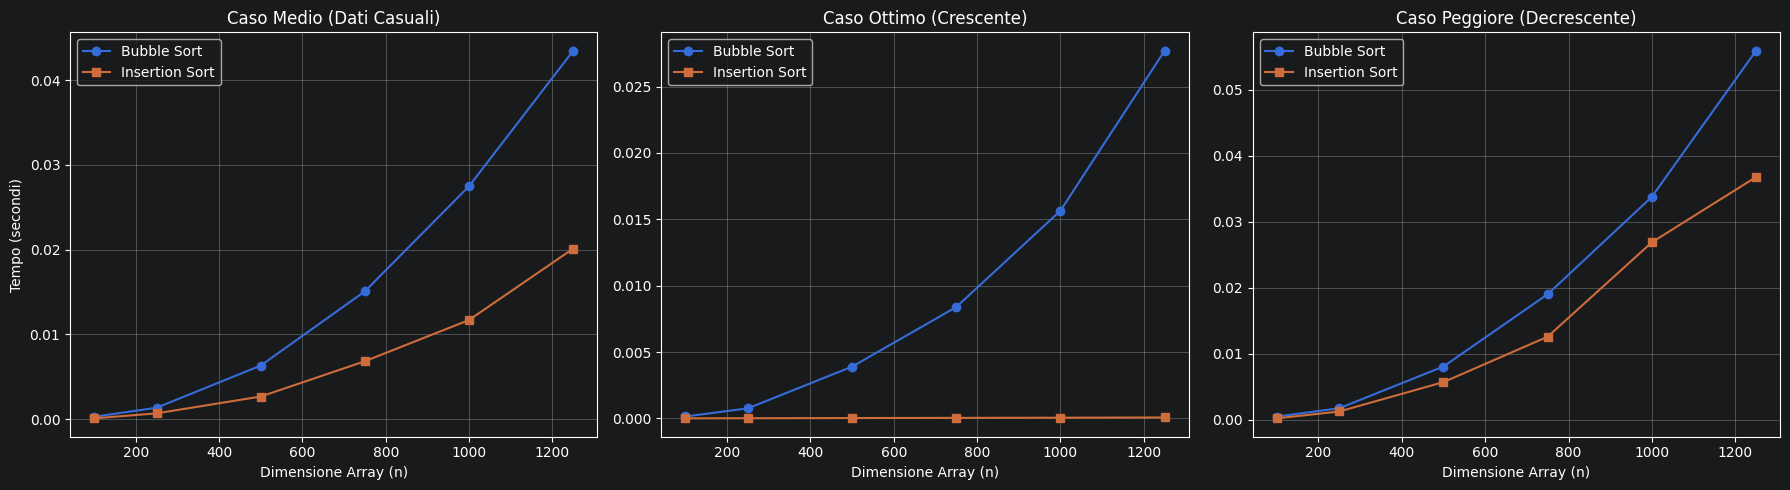

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# Grafico 1: Caso Medio (Casuale)
plt.subplot(1, 3, 1)
plt.plot(sizes, results["bubble_random"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_random"], 's-', label='Insertion Sort')
plt.title("Caso Medio (Dati Casuali)")
plt.xlabel("Dimensione Array (n)")
plt.ylabel("Tempo (secondi)")
plt.legend()
plt.grid(True)

# Grafico 2: Caso Ottimo (Già Ordinato)
plt.subplot(1, 3, 2)
plt.plot(sizes, results["bubble_sorted"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_sorted"], 's-', label='Insertion Sort')
plt.title("Caso Ottimo (Crescente)")
plt.xlabel("Dimensione Array (n)")
plt.legend()
plt.grid(True)

# Grafico 3: Caso Peggiore (Decrescente)
plt.subplot(1, 3, 3)
plt.plot(sizes, results["bubble_reverse"], 'o-', label='Bubble Sort')
plt.plot(sizes, results["insertion_reverse"], 's-', label='Insertion Sort')
plt.title("Caso Peggiore (Decrescente)")
plt.xlabel("Dimensione Array (n)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()